In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft
import pandas as pd
from scipy import signal
import seaborn as sns
from scipy.special import comb
sns.set()

# 9章演習問題

## (1)
ノート

## (2) $h_N(n)　= \frac{1}{2^{N-1}}{}_{N-1}C_{n}, \quad n=0 \sim N-1$

### (a) 伝達関数 

\begin{align*}
H(z) &= \frac{1}{2^{N-1}}\Sigma_{n=-\infty}^{\infty}{}_{N}C_{n}z^{-n}\\
&= \frac{1}{2^{N-1}}\Sigma_{n=0}^{N-1}{}_{N}C_{n}z^{-n}\\
&= \frac{1}{2^{N-1}}(1 + z^{-1})^{N-1}
\end{align*}

### (b) $h_N(n)$が線形位相特性を持つ低域フィルタであることを示せ

(a)の結果から，
\begin{align*}
H(e^{j\omega}) &= \frac{1}{2^{N-1}}(1 + e^{-j\omega})^{N-1}\\
&= \frac{1}{2^{N-1}}\left(e^{-j\frac{\omega}{2}}\left(e^{j\frac{\omega}{2}} + e^{-j\frac{\omega}{2}}\right)\right)^{N-1}\\
&= \frac{1}{2^{N-1}}e^{-j\frac{\omega}{2}N}\left(2\cos \frac{\omega}{2} \right)^{N-1}\\
&= e^{-j\frac{\omega}{2}N}\left(\cos \frac{\omega}{2} \right)^{N-1},\\
|H(e^{j\omega})| &= \left|\cos \frac{\omega}{2} \right|^{N-1}, \\
\theta(\omega) &=-\frac{\omega N}{2}
\end{align*}

上式から，位相特性は線形で，振幅特性は$\omega=0$で1，$\omega=\pi$で０，その間は単調減少の低域フィルタとなっている．


### (c) 遮断周波数

\begin{align*}
|H(e^{j\omega})|_{\omega=\omega_c} &= \left|\cos \frac{\omega_c}{2} \right|^{N-1} = \frac{1}{\sqrt{2}},\\
\left|\cos\frac{\omega_c}{2}\right| &= 2^{-\frac{1}{2}\cdot \frac{1}{N-1}},\\
\omega_c &= 2\cos^{-1} 2^{-\frac{1}{2(N-1)}}
\end{align*}


### (d) 単位インパルス応答，振幅特性，位相特性

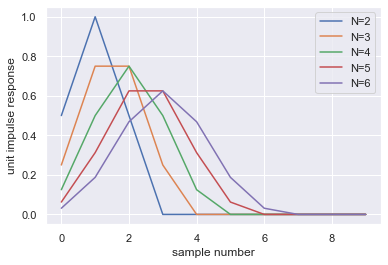

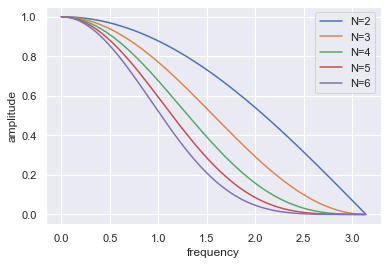

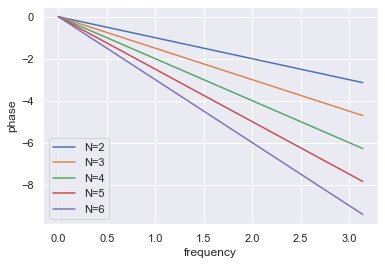

In [2]:
Nlist = [2, 3, 4, 5, 6]

m = 10
for N in Nlist:
    c = 1.0 / (2**(N-1))
    h = np.zeros(m)
    for i in range(m):
        h[i] = c * comb(N, i, exact=True)
    plt.plot(range(m), h, label="N="+str(N))
plt.ylabel("unit impulse response")
plt.xlabel("sample number")
plt.legend()
plt.show()

omega = np.linspace(0, np.pi, 1024, endpoint=False)

i = 1
for N in Nlist:
    absH = np.cos(omega / 2.0) ** (N-1)
    plt.plot(omega, absH, label="N="+str(N))
plt.ylabel("amplitude")
plt.xlabel("frequency")
plt.legend()
plt.show()

for N in Nlist:    
    argH = -omega * N / 2.0
    plt.plot(omega, argH, label="N="+str(N))
plt.ylabel("phase")
plt.xlabel("frequency")
plt.legend()
plt.show()

## (3)

### (a) 極零配置

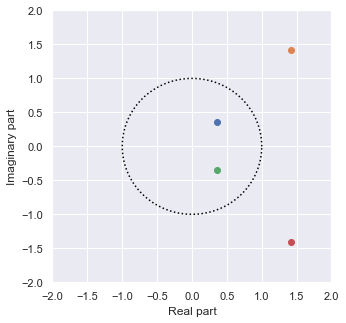

In [15]:
r = 0.5
theta = np.pi / 4.0
plt.figure(figsize=(5, 5))

plt.scatter(r*np.cos(theta), r*np.sin(theta))
plt.scatter((1/r)*np.cos(theta), (1/r)*np.sin(theta))
plt.scatter(r*np.cos(-theta), r*np.sin(-theta))
plt.scatter((1/r)*np.cos(-theta), (1/r)*np.sin(-theta))

theta = np.linspace(0, 2*np.pi, 360)
plt.plot(np.cos(theta), np.sin(theta), c="black", linestyle="dotted")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.show()

### (b)　位相特性

\begin{align*}
H(z) = \left(1 - re^{j\theta}z^{-1}\right)\left(1 - \frac{1}{r}e^{j\theta}z^{-1}\right)
\left(1 - re^{-j\theta}z^{-1}\right)\left(1 - \frac{1}{r}e^{-j\theta}z^{-1}\right)
\end{align*}

式展開すると
\begin{align*}
H(z) &= 1 - 2\cos \theta (r + 1/r)z^{-1} + (2 + r^2 + 1/r^2 + 2\cos \theta)z^{-2} - 2\cos \theta(r+1/r)z^{-3} + z^{-4}
\end{align*}

$c_0=-2\cos \theta(r+1/r)$，$c_1=2+r^2+1/r^2+2\cos \theta$と置いて，整理すると
\begin{align*}
H(e^{j\omega}) &= 1 + e^{-j4\omega} -c_0\left(e^{-j\omega}+e^{-j3\omega} \right) + c_1 e^{-j2\omega}\\
&= e^{-j2\omega}\left(e^{j2\omega} + e^{-j2\omega}\right) -c_0e^{-j2\omega}\left(e^{j\omega}+e^{-j\omega} \right)
+ c_1 e^{-j2\omega}\\
&= \left( 2\cos 2\omega - c_0 \cos \omega + c_1 \right)e^{-j2\omega}
\end{align*}
上の式から位相特性は$\theta(\omega)=-2\omega$で線形位相特性となっている．

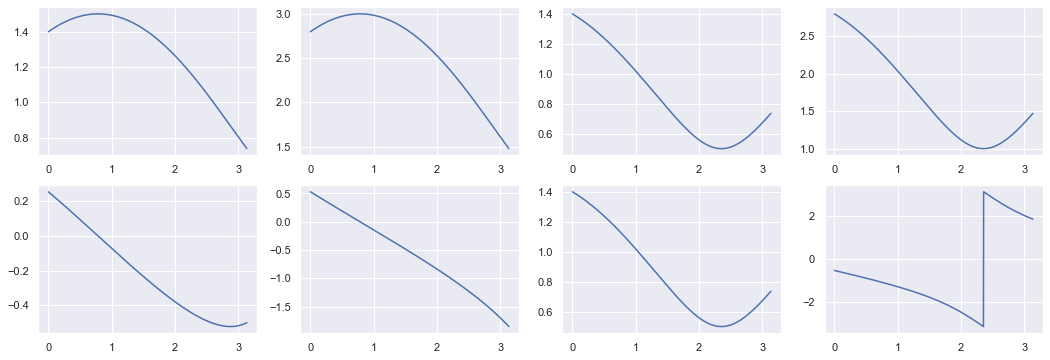

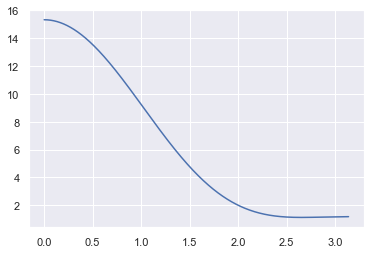

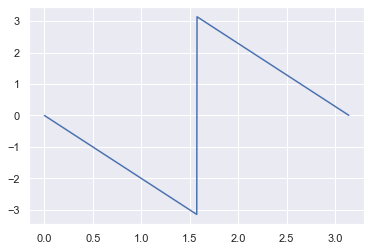

In [30]:
omega = np.linspace(0, np.pi, 1024, endpoint=False)

r = 0.5
theta = np.pi / 4.0
h0 = [1.0, r * np.exp(complex(0.0, theta))]
h1 = [1.0, (1.0/r) * np.exp(complex(0.0, theta))]
h2 = [1.0, r * np.exp(complex(0.0, -theta))]
h3 = [1.0, (1.0/r) * np.exp(complex(0.0, -theta))]

_, H0 = signal.freqz(h0, 1.0, omega)
_, H1 = signal.freqz(h1, 1.0, omega)
_, H2 = signal.freqz(h2, 1.0, omega)
_, H3 = signal.freqz(h3, 1.0, omega)


absH0 = np.abs(H0)
argH0 = np.angle(H0)
absH1 = np.abs(H1)
argH1 = np.angle(H1)
absH2 = np.abs(H2)
argH2 = np.angle(H2)
absH3 = np.abs(H3)
argH3 = np.angle(H3)

plt.figure(figsize=(18,6))
plt.subplot(2, 4, 1)
plt.plot(omega, absH0)
plt.subplot(2, 4, 2)
plt.plot(omega, absH1)
plt.subplot(2, 4, 3)
plt.plot(omega, absH2)
plt.subplot(2, 4, 4)
plt.plot(omega, absH3)

plt.subplot(2, 4, 5)
plt.plot(omega, argH0)
plt.subplot(2, 4, 6)
plt.plot(omega, argH1)
plt.subplot(2, 4, 7)
plt.plot(omega, absH2)
plt.subplot(2, 4, 8)
plt.plot(omega, argH3)
plt.show()

H = H0 * H1 * H2 * H3
absH = np.abs(H)
argH = np.angle(H)

plt.plot(omega, absH)
plt.show()
plt.plot(omega, argH)
plt.show()

## (4) カーディナルサイン関数

### (a)${\rm sinc} t = \frac{\sin \pi t}{\pi t}$の証明

\begin{align*}
\frac{1}{2\pi}\int_{-\pi}^{\pi}e^{j\omega t}d\omega
&= \frac{1}{2\pi}\int_{-\pi}^{\pi}(\cos \omega t + j\sin \omega t)d\omega\\
&= \frac{1}{2\pi}\left[\frac{1}{t}\sin \omega t - j\frac{1}{t}\cos \omega t \right]^{\pi}_{-\pi}\\
&= \frac{1}{2\pi t}\left[\sin \omega t - j\cos \omega t \right]^{\pi}_{-\pi}\\
&= \frac{1}{2\pi t}(\sin \pi t - j\cos \pi t - \sin (-\pi t) + j\cos (-\pi t) )\\
&= \frac{\sin \pi t}{\pi t}\\
\end{align*}


### (b) $\lim_{t \to 0} {\rm sinc} t = 1$の証明

\begin{align*}
\lim_{t \to 0} {\rm sinc} t &= \lim_{t \to 0}\frac{1}{2\pi}\int_{-\pi}^{\pi}e^{j\omega t}d\omega\\
&= \frac{1}{2\pi}\int_{-\pi}^{\pi}1d\omega\\
&= \frac{1}{2\pi}2\pi = 1
\end{align*}

### (c) sinc関数の図示

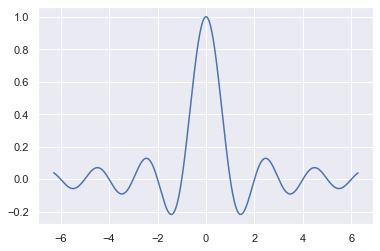

In [3]:
omega = np.linspace(-2*np.pi, 2*np.pi, 1024, endpoint=False)
plt.plot(omega, np.sinc(omega))
plt.show()

In [4]:
def mysinc(t):
    if t != 0.0:
        sinc_t = np.sin(np.pi * t)/ (np.pi * t)
    else:
        sinc_t = 1.0
    return sinc_t

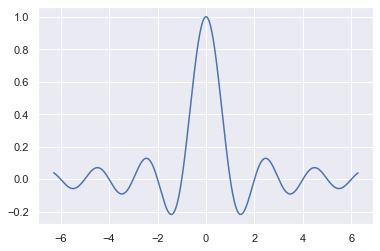

In [5]:
omega = np.linspace(-2*np.pi, 2*np.pi, 1024, endpoint=False)
sc = np.zeros_like(omega)
for i in range(len(omega)):
    sc[i] = mysinc(omega[i])
plt.plot(omega, sc)
plt.show()

### (d) 単位インパルス応答

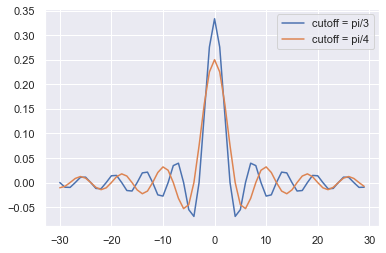

In [6]:
for omegac, stromegac in zip([np.pi/3.0, np.pi/4.0], ["pi/3","pi/4"]):
    x = omegac / np.pi
    hd = []
    ns = np.arange(-30, 30)
    for n in ns:
        hd.append(x * np.sinc(x * n))
    plt.plot(ns, hd, label="cutoff = "+stromegac)
plt.legend()
plt.show()

## (5) FIRフィルタの設計

### (a) ハニング窓を用いた設計

N= 63 M= 31 Rp= 0.10292004270447044


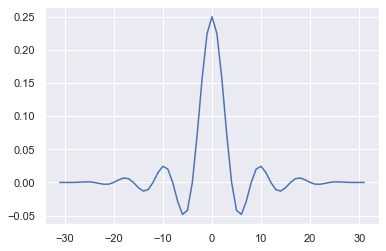

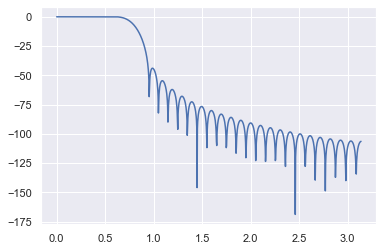

In [7]:
def hanning(n, N):
    return 0.5 + 0.5 * np.cos(2.0*np.pi*n/(N-1))

omega = np.linspace(0, np.pi, 1024, endpoint=False)
omega_s = 0.3 * np.pi
omega_p = 0.2 * np.pi
omega_c = (omega_s + omega_p) / 2.0
omega_c_pi = omega_c / np.pi

thRp = 0.25

M = 31
for M in np.arange(31, 100):
    N = 2 * M + 1
    h = np.zeros(N)
    i = 0
    for n in np.arange(-M, M+1):
        h[i] = omega_c_pi * mysinc(omega_c_pi * n) * hanning(n, N)
        i+=1
    _, H = signal.freqz(h, 1.0, omega)
    absH = np.abs(H)
    absHdB = -20 * np.log10(absH / absH.max())
    Rp = 0.0
    for i in range(len(absHdB)):
        if omega[i] <= omega_p:
            if absHdB[i] > Rp:
                Rp = absHdB[i]
                
    #print(M, Rp)
    if Rp < thRp:
        break

print("N=",N, "M=",M, "Rp=",Rp)
plt.plot(np.arange(-M, M+1), h)
plt.show()

plt.plot(omega, -absHdB)
plt.show()

### (c) 窓違い

N= 111 M= 55 Rp= 0.0029931707646388495


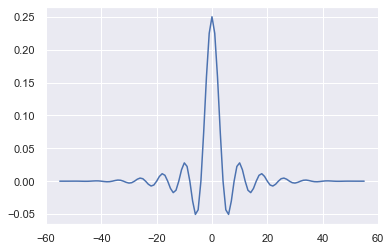

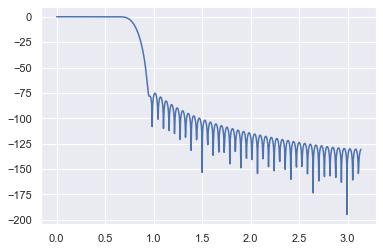

In [8]:
def blackman(n, N):
    return 0.42 + 0.5 * np.cos(2.0*np.pi*n/(N-1)) + 0.08 * np.cos(4.0*np.pi*n/(N-1))

omega = np.linspace(0, np.pi, 1024, endpoint=False)
omega_s = 0.3 * np.pi
omega_p = 0.2 * np.pi
omega_c = (omega_s + omega_p) / 2.0
omega_c_pi = omega_c / np.pi

thRp = 0.25

for M in np.arange(55, 100):
    N = 2 * M + 1
    h = np.zeros(N)
    i = 0
    for n in np.arange(-M, M+1):
        h[i] = omega_c_pi * mysinc(omega_c_pi * n) * blackman(n, N)
        i+=1
    _, H = signal.freqz(h, 1.0, omega)
    absH = np.abs(H)
    absHdB = -20 * np.log10(absH / absH.max())
    Rp = 0.0
    for i in range(len(absHdB)):
        if omega[i] <= omega_p:
            if absHdB[i] > Rp:
                Rp = absHdB[i]
                
    #print(M, Rp)
    if Rp < thRp:
        break

print("N=",N, "M=",M, "Rp=",Rp)
plt.plot(np.arange(-M, M+1), h)
plt.show()

plt.plot(omega, -absHdB)
plt.show()

## (6)

### (a) 遮断周波数
振幅特性
\begin{align*}
H_L(z) &= \frac{1}{4}(z + 2 + z^{-1})\\
H_L(e^{j\omega}) &= \frac{1}{4}(e^{j\omega} + 2 + e^{-j\omega})\\
&= \frac{1}{2}(1 + \cos \omega)
\end{align*}

遮断周波数
\begin{align*}
\frac{1}{2}(1 + \cos \omega_{cL}) &= \frac{1}{\sqrt{2}}\\
\cos \omega_{cL} &= \sqrt{2} - 1\\
\omega_{cL} &= \cos^{-1}\left(\sqrt{2}-1\right)
\end{align*}


### (b)

i. 高域フィルタ

\begin{align*}
H_H(e^{j\omega}) &= H_L(e^{j(\omega-\pi)}) = \frac{1}{2}(1+\cos (\omega-\pi))\\
&= \frac{1}{2}(1 - \cos \omega)
\end{align*}

\begin{align*}
h_H(n) &= (-1)^n h_L(n) = \frac{1}{4}[(-1)^{-1}1, (-1)^{0}\underline{2}, (-1)^11]\\
&=  \frac{1}{4}[-1, \underline{2}, -1]
\end{align*}

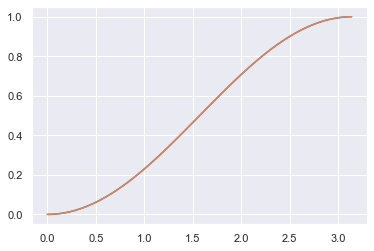

In [9]:
omega = np.linspace(0, np.pi, 1024, endpoint=False)
hH = np.array([-1, 2, -1]) / 4.0

_, H = signal.freqz(hH, 1.0, omega)
absH = np.abs(H)
    
plt.plot(omega, absH)
plt.plot(omega, 0.5*(1.0-np.cos(omega)))
plt.show()

ii. 帯域フィルタ

\begin{align*}
H_{BP}(e^{j\omega}) &= H_L(e^{j(\omega-\omega_0)}) + H_L(e^{j(\omega+\omega_0)})\\
&= \frac{1}{2}(1+\cos (\omega-\omega_0)) + \frac{1}{2}(1+\cos (\omega+\omega_0))
\end{align*}
$\omega_0=\pi/2$から，

\begin{align*}
H_{BP}(e^{j\omega}) &= \frac{1}{2}\left(1+\cos \left(\omega-\frac{\pi}{2}\right)\right)
+ \frac{1}{2}\left(1+\cos \left(\omega+\frac{\pi}{2} \right) \right)　= 1?
\end{align*}

\begin{align*}
h_{BP}(n) &= 2\cos n\omega_0 h_L(n) = \frac{1}{4}[2\cos -\frac{\pi}{2}\cdot 1, 2\cos 0\cdot \underline{2}, 2\cos\frac{\pi}{2}\cdot 1]\\
&=  \frac{1}{4}[0, \underline{4}, 0]
\end{align*}

## (7) 
### (a) $h_H(n)=\delta(n) - h_1(n)$

単位インパルス応答の離散時間フーリエ変換は1であることと，z変換の線形性から

\begin{align*}
H_H(e^{j\omega}) &= 1 - H_1(e^{j\omega})\\
\end{align*}

$H_1(e^{j\omega})$は零位相の理想的低域フィルタの特性なので，
$1 - H_1(e^{j\omega})$は理想的高域フィルタとなる．

### (b) $h_1(n)$,$h_2(n)$からBPFとBSFを実現する

(a)と同様に
\begin{align*}
H_{BP}(e^{j\omega}) &= H_2(e^{j\omega}) - H_1(e^{j\omega})\\
\end{align*}


\begin{align*}
H_{BS}(e^{j\omega}) &= 1 - (H_2(e^{j\omega}) - H_1(e^{j\omega}))\\
\end{align*}



## (8) 理想ディジタル微分器

### (a) 振幅特性，位相特性

振幅特性
\begin{align*}
|H_d(e^{j\omega})|^2 &= H_d(e^{j\omega})H^{*}_d(e^{j\omega}) = \omega^2\\
|H_d(e^{j\omega})| &= \omega
\end{align*}

位相特性
\begin{align*}
\theta(\omega) &=
\left\{ \,
    \begin{aligned}
     &\pi/2, \quad 0<\omega<\pi \\
     -&\pi/2, \quad -\pi<\omega<0
    \end{aligned}
\right.
\end{align*}

### (b) 単位インパルス応答の導出

\begin{align*}
h_d(n)&= \frac{1}{2\pi}\int_{-\pi}^{\pi}H_d(e^{j\omega})e^{j\omega n}d\omega\\
&= \frac{j}{2\pi}\left( \int_{-\pi}^{\pi} \omega e^{j\omega n}d\omega \right)　\label{a}\tag{1}\\
\end{align*}

$n=0$のとき，
\begin{align*}
(\ref{a}) &= \frac{j}{2\pi}\left( \int_{-\pi}^{\pi}\omega d\omega \right) = 0\\
\end{align*}

$n\neq 0$のとき，
\begin{align*}
(\ref{a}) &= \frac{j}{2\pi}\left( \int_{-\pi}^{\pi} \omega \frac{1}{jn} \frac{d}{d\omega}e^{j\omega n} d\omega \right)\\
&= \frac{1}{2\pi n}\left( \left[ \omega e^{j\omega n} \right]_{-\pi}^{\pi} -\int_{-\pi}^{\pi}e^{j\omega n}d\omega \right)\\
&= \frac{1}{2\pi n}\left( \pi \left(e^{j\pi n} + e^{-j\pi n} \right)
- \frac{1}{jn}\left[ e^{j\omega n} \right]_{-\pi}^{\pi}  \right)\\
&= \frac{1}{2\pi n}\left( 2\pi \cos \pi n -\frac{1}{jn}\left( e^{j\pi n} - e^{-j\pi n} \right) \right)\\
&= \frac{\cos \pi n}{n}
\end{align*}

### (c) 単位インパルス応答の図示

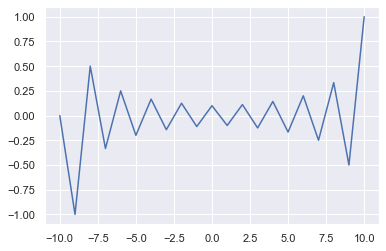

In [10]:
ns = np.arange(-10, 11)
h = np.zeros(21)

for n in ns:
    if n == 0:
        h[n] = 0.0
    else:
        h[n] = np.cos(np.pi * n) / n
    
plt.plot(ns, h)
plt.show()

### (d) 長さ21のハミング窓で設計

<ipython-input-11-16e01c314bf5>:23: RuntimeWarning: divide by zero encountered in log10
  absHdB = -20 * np.log10(absH / absH.max())


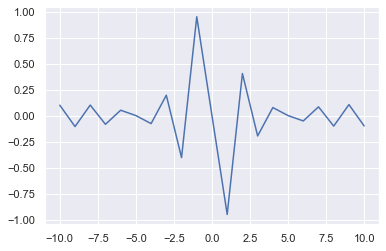

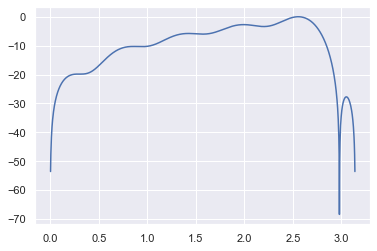

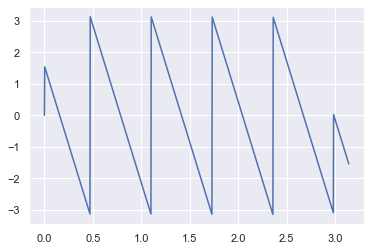

In [11]:
def hamming(n, N):
    return np.cos(2.0*np.pi*n/(N-1))

omega = np.linspace(0, np.pi, 1024, endpoint=False)

M = 10
N = 21
h = np.zeros(N)

i = 0
for n in np.arange(-M, M+1):
    if n == 0:
        h[i] = 0.0
    else:
        h[i] = (np.cos(np.pi * n)/n) * hamming(n, N)
        
    #print(i, n, N, hamming(n, N), h[i])
        
    i+=1
_, H = signal.freqz(h, 1.0, omega)
absH = np.abs(H)
argH = np.angle(H)
absHdB = -20 * np.log10(absH / absH.max())

plt.plot(np.arange(-M, M+1), h)
plt.show()

plt.plot(omega, -absHdB)
plt.show()

plt.plot(omega, argH)
plt.show()

## (9) 理想ヒルベルト変換器

### (a) 振幅特性，位相特性

振幅：1

位相：

\begin{align*}
\theta(\omega) &=
\left\{ \,
    \begin{aligned}
     -&\pi/2, \quad 0<\omega<\pi \\
     &\pi/2, \quad -\pi<\omega<0
    \end{aligned}
\right.
\end{align*}

### (b)

\begin{align*}
h_d(n)&= \frac{1}{2\pi}\int_{-\pi}^{\pi}H_d(e^{j\omega})e^{j\omega n}d\omega\\
&= \frac{j}{2\pi}\left( \int_{-\pi}^{0}e^{j\omega n}d\omega - \int_{0}^{\pi}e^{j\omega n}d\omega \right)　\label{a}\tag{1}\\
\end{align*}

$n=0$のとき，
\begin{align*}
(\ref{a}) &= \frac{j}{2\pi}\left( \int_{-\pi}^{0}1d\omega - \int_{0}^{\pi}1d\omega \right) = 0\\
\end{align*}

$n\neq 0$のとき，

\begin{align*}
(\ref{a}) &= \frac{j}{2\pi}\left( \left[ \frac{1}{jn}e^{j\omega n} \right]_{-\pi}^{0}
- \left[ \frac{1}{jn}e^{j\omega n} \right]_{0}^{\pi} \right)\\
&= \frac{1}{2\pi n}\left(2 - \left( e^{j\pi n} + e^{-j\pi n}\right) \right)\\
&= \frac{1}{2\pi n}\left(2 - 2\cos \pi n \right)\\
&= \frac{1}{\pi n}\left(1 - \left( 1 - 2\sin^2 \frac{\pi n}{2} \right) \right)\\
&= \frac{2}{\pi n}\sin^2 \frac{\pi n}{2}
\end{align*}

### (c) インパルス応答

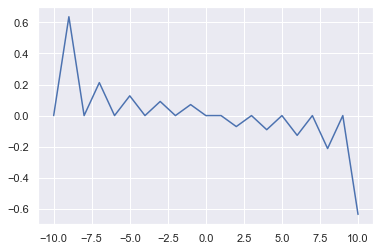

In [12]:
ns = np.arange(-10, 11)
h = np.zeros(21)

for n in ns:
    if n == 0:
        h[n] = 0.0
    else:
        h[n] = (2.0/np.pi) * np.sin(np.pi * n / 2.0)**2 / n
    
plt.plot(ns, h)
plt.show()

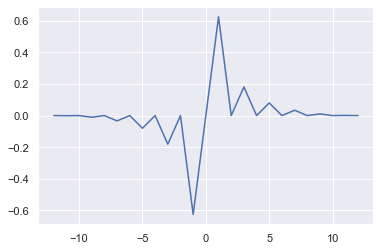

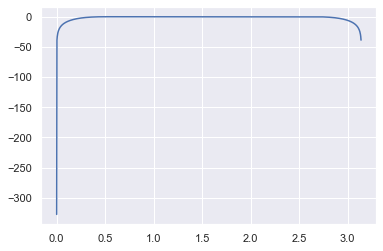

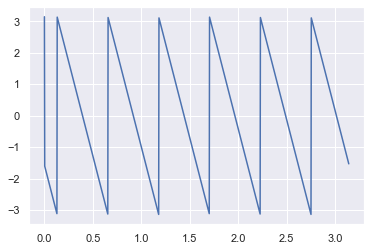

In [13]:
omega = np.linspace(0, np.pi, 1024, endpoint=False)

M = 12
N = 25
h = np.zeros(N)

i = 0
for n in np.arange(-M, M+1):
    if n == 0:
        h[i] = 0.0
    else:
        h[i] = (2.0/np.pi) * np.sin(np.pi * n / 2.0)**2 / n * hanning(n, N)
        
    #print(i, n, N, hamming(n, N), h[i])
        
    i+=1
_, H = signal.freqz(h, 1.0, omega)
absH = np.abs(H)
argH = np.angle(H)
absHdB = -20 * np.log10(absH / absH.max())

plt.plot(np.arange(-M, M+1), h)
plt.show()

plt.plot(omega, -absHdB)
plt.show()

plt.plot(omega, argH)
plt.show()